In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd

import matplotlib.pyplot as plt
from   matplotlib.path import Path

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

# Import des données

In [2]:
# Tableau : Ne-HCN
Ne = np.genfromtxt("Data/Ne-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
energy_mEh = Ne['Energy'] * 1e-3
# Ajout de la colonne en Eh
Ne = rfn.append_fields(Ne, names='Energy_mEh', data=energy_mEh, usemask=False)

# Parametres donnés par Toczylowski
params_Ne = np.array([ 1.39799,   0.06304,   0.10472,   0.10103,   0.04239, -0.00674,  # b
                      -33692.705,-209959.32,-16394.597,-107262.52,                     # c
                       13.60561,  0.87434,   2.39464,   0.60195,   0.31713,  0.05930,  # d
                       0.10500,  -0.06621,  -0.05328,   0.01479,   0.00609, -0.00197,  # g0
                      -0.03368,   0.02788,   0.02191,  -0.00483,  -0.00308,  0.00011,  # g1
                       0.00374,  -0.00401,  -0.00298,   0.00070,   0.00054,  0.00004,  # g2
                      -0.000154,  0.000203,  0.000141, -0.000046, -0.000033,-0.000002])# g3

# Implémentation des fonctions

In [3]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [4]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [5]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [6]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [7]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [8]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [9]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## Calculs

In [10]:
R = np.asarray(Ne["R"], dtype=float)
Theta = np.asarray(Ne["Theta"], dtype=float)
V_table = np.asarray(Ne["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((151,), (151,), (151,))

In [11]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [12]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.3798335781166986, 0.0747101713032491, 0.11462267313147378, 0.09664016790078946, 0.04824860308272037, -0.022459788692016428]
[c0,c1,c2,c3]             = [-32839.02499992673, -206101.40612772066, -16096.029229923657, -111550.82381149399]
[d0,d1,d2,d3,d4,d5]       = [13.48203219463485, 0.682998438004234, 2.2967935279045855, 0.5515746147485603, 0.33917141878370094, -0.022269429590615595]
[g00,g01,g02,g03,g04,g05] = [0.10851406112927854, -0.050780519895218194, -0.05435318350903608, 0.0070953583386222365, 0.006104443320650716, 0.0029754169384116707]
[g10,g11,g12,g13,g14,g15] = [-0.03476660100147735, 0.024063278134583494, 0.024538643136121176, -0.0007985316860262591, -0.0030153253978342114, -0.0019289934436983738]
[g20,g21,g22,g23,g24,g25] = [0.0038323603851219646, -0.0036857084188698956, -0.0035317976909017834, 5.1747832303294926e-05, 0.0005749641261242175, 0.0003305529380051339]
[g30,g31,g32,g33,g34,g35] = [-0.0001554725724325855, 0.0001910854932243665, 0.0001

In [13]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 1.37983358e+00  7.47101713e-02  1.14622673e-01  9.66401679e-02
  4.82486031e-02 -2.24597887e-02 -3.28390250e+04 -2.06101406e+05
 -1.60960292e+04 -1.11550824e+05  1.34820322e+01  6.82998438e-01
  2.29679353e+00  5.51574615e-01  3.39171419e-01 -2.22694296e-02
  1.08514061e-01 -5.07805199e-02 -5.43531835e-02  7.09535834e-03
  6.10444332e-03  2.97541694e-03 -3.47666010e-02  2.40632781e-02
  2.45386431e-02 -7.98531686e-04 -3.01532540e-03 -1.92899344e-03
  3.83236039e-03 -3.68570842e-03 -3.53179769e-03  5.17478323e-05
  5.74964126e-04  3.30552938e-04 -1.55472572e-04  1.91085493e-04
  1.71545507e-04 -1.08790363e-05 -3.83812740e-05 -1.60254896e-05]
[ 1.34941715e+00  4.24254444e-02  5.82015952e-02  4.94665434e-02
  2.65344892e-03 -1.31053158e-02 -3.15706413e+04 -2.86617347e+05
 -1.43102105e+04 -7.33368753e+04  1.33802670e+01  8.89411776e-01
  1.68029966e+00  5.24249568e-01  7.87606393e-02 -5.69535895e-02
  1.20396035e-01 -8.68064598e-02  2.75022254e-02  1.08888442e-03
  2.07388316e-02  8.8024

In [14]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_Ne, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

rmse_cf = rmse(V_table, V_pred_cf)
rmse_cf_sigma = rmse(V_table, V_pred_cf_sigma)
rmse_params_these = rmse(V_table, V_params_these)

mae_cf = mae(V_table, V_pred_cf)
mae_cf_sigma = mae(V_table, V_pred_cf_sigma)
mae_params_these = mae(V_table, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999999535540628
R² (avec sigma=y)       : 0.9999916460178048
R² (paramètres these)   : 0.9992698330368525

rmse (sans sigma)       : 0.0005543392580263035
rmse (avec sigma=y)     : 0.00743444483905847
rmse (paramètres these) : 0.06950448990705554

mae (sans sigma)        : 0.0004275704288413842
mae (avec sigma=y)      : 0.002093705952391835
mae (paramètres these)  : 0.027594551913241342


# Affichage des résultats

## Plot à variable fixée

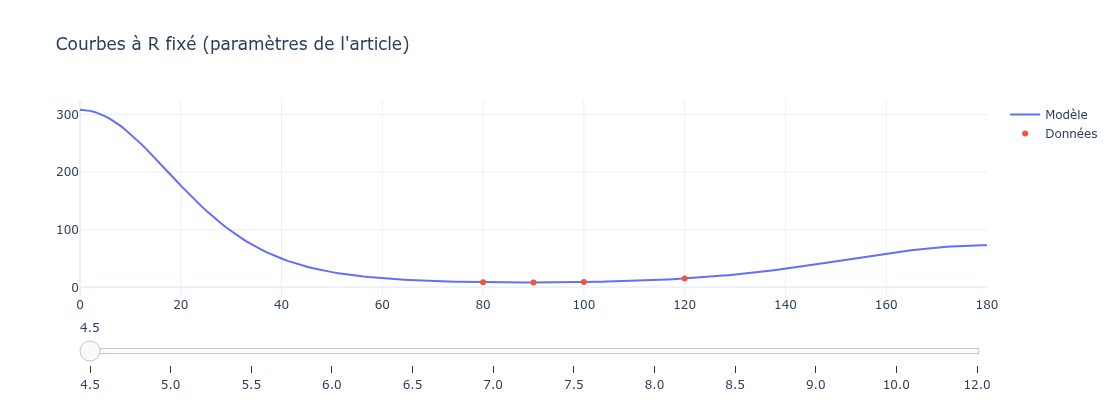

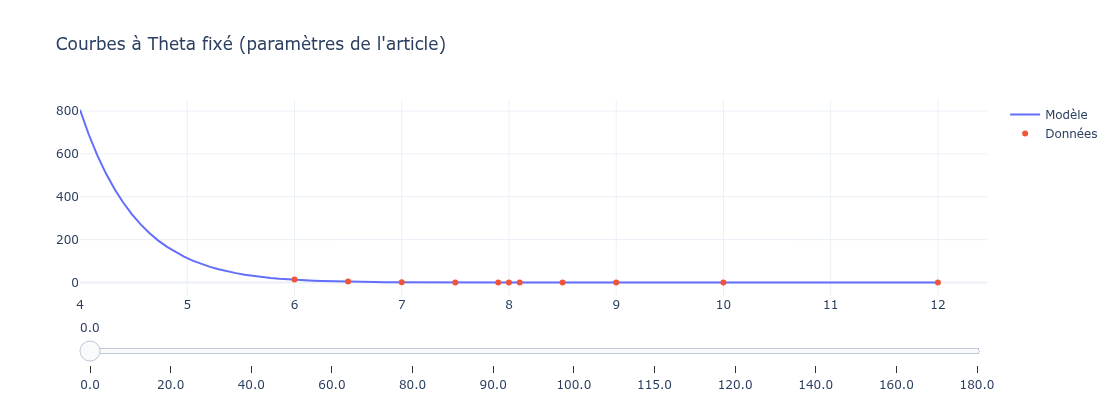

In [15]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_Ne, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_Ne, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

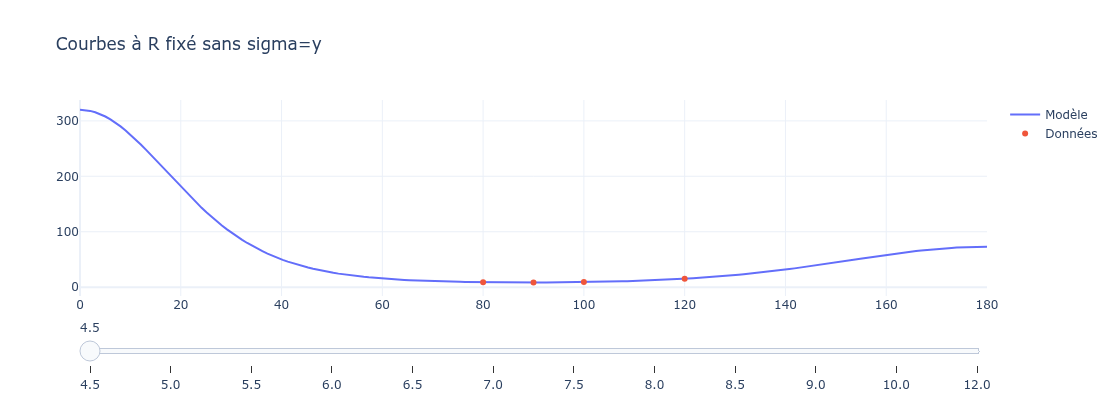

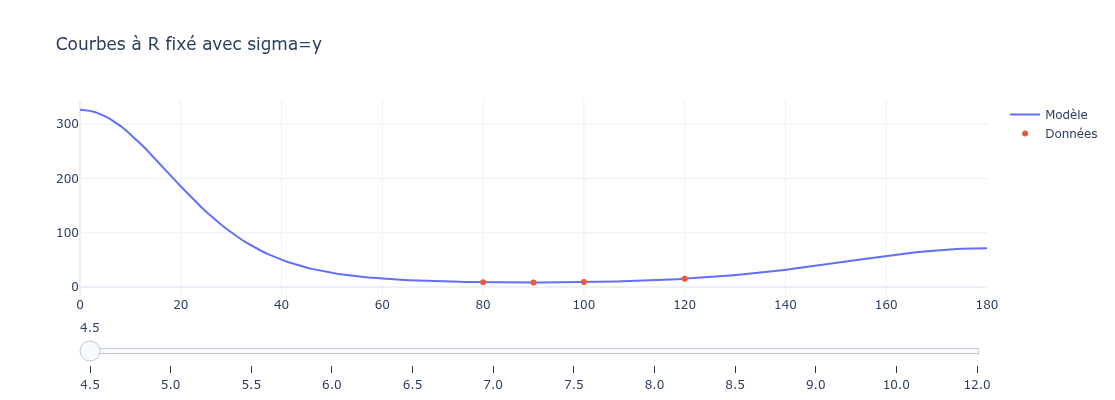

In [16]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

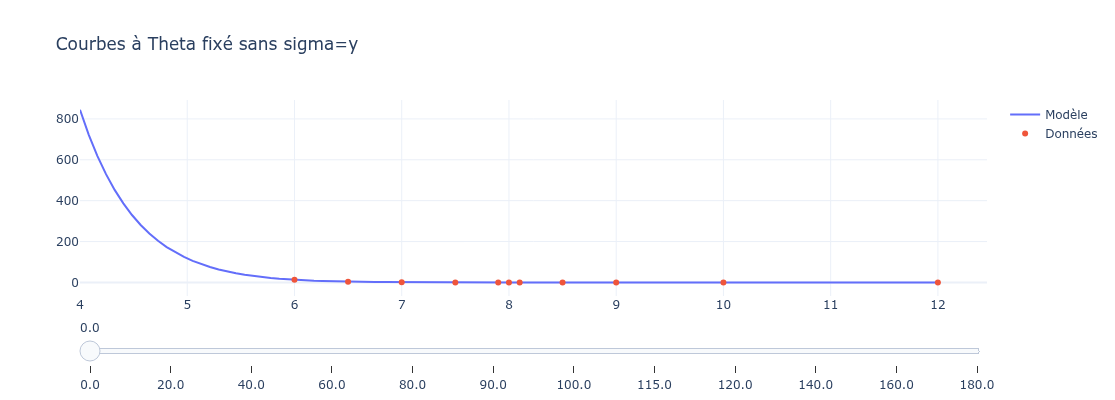

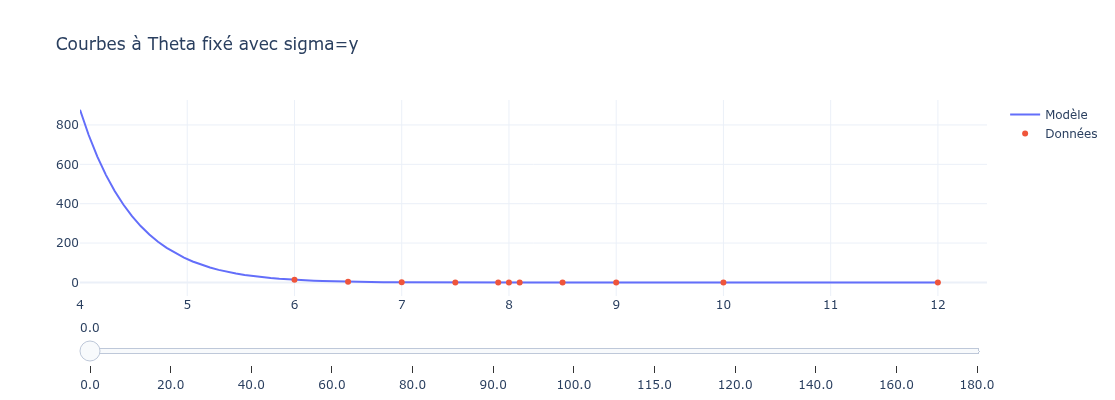

In [17]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [18]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.084, -0.106, -0.128, -0.147, -0.166,
        -0.1845, -0.203, -0.222, -0.241, -0.252
    ])
    
    levels_with_labels = np.array([
        -0.084, -0.128, -0.166,
        -0.203, -0.222, -0.241, -0.252
    ])
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)
    
    ax.set_title(f"Ne-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

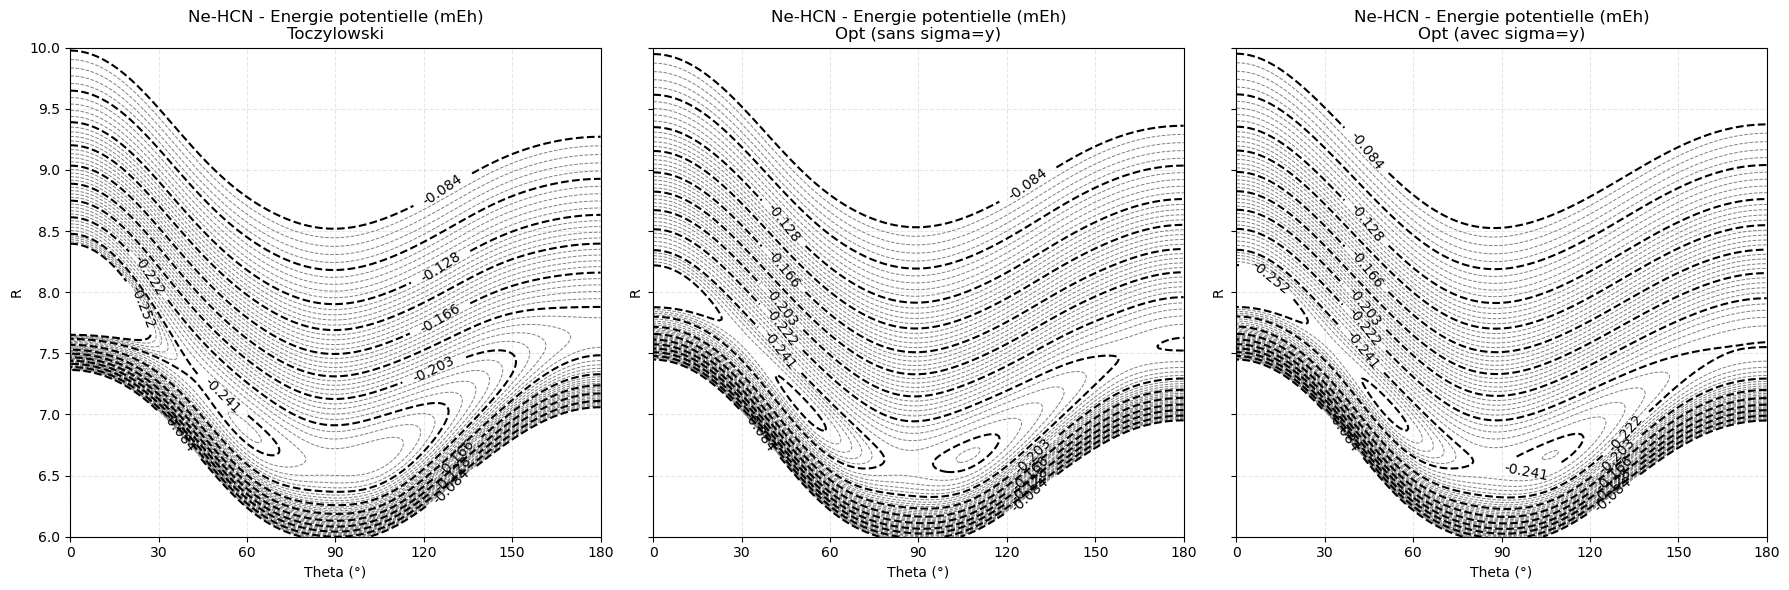

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_Ne, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Méthode 2 : least_squares

In [27]:
def residus_Ne(params):
    V_pred = V_opt(params, Ne["R"], Ne["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - Ne["Energy_mEh"]).ravel()

In [28]:
result1 = least_squares(residus_Ne, params_Ne)
params_opt_ls = result1.x

result2 = least_squares(residus_Ne, params_Ne, x_scale = "jac")
params_opt_ls_jac = result2.x

In [29]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)

r2_ls = rsq(V_table, V_pred_ls)
r2_ls_jac = rsq(V_table, V_pred_ls_jac)
rmse_ls = rmse(V_table, V_pred_ls)
rmse_ls_jac = rmse(V_table, V_pred_ls_jac)
mae_ls = mae(V_table, V_pred_ls)
mae_ls_jac = mae(V_table, V_pred_ls_jac)

print(f"R²                   : {r2_ls}")
print(f"R²   (x_scale='jac') : {r2_ls_jac}")
print()
print(f"rmse                 : {rmse_ls}")
print(f"rmse (x_scale='jac') : {rmse_ls_jac}")
print()
print(f"mae                  : {mae_ls}")
print(f"mae  (x_scale='jac') : {mae_ls_jac}")

R²                   : 0.9999999503526615
R²   (x_scale='jac') : 0.9999999535540629

rmse                 : 0.0005731255325990076
rmse (x_scale='jac') : 0.0005543392571510669

mae                  : 0.00042964692854888226
mae  (x_scale='jac') : 0.00042757001719500134


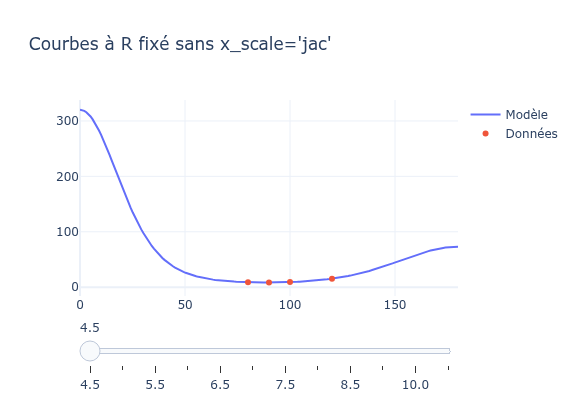

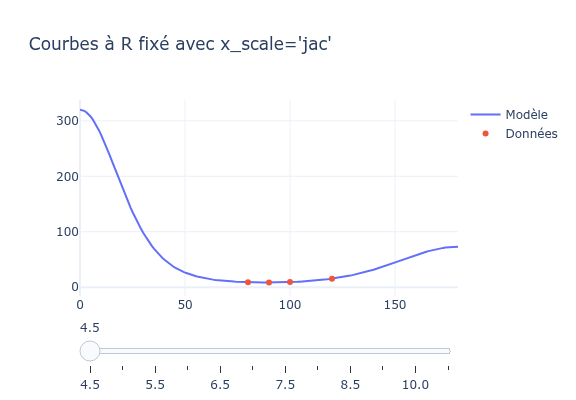

In [30]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")